# Лабораторная работа №1: Классификация изображений с помощью CNN

## Цель работы
Научиться строить и обучать сверточные нейронные сети (CNN) для классификации изображений, изучить влияние аугментации данных, архитектурных решений и гиперпараметров на качество модели.

---

## Задание

### Часть 1. Базовая модель CNN
1. Загрузите датасет **CIFAR-10** с нормализацией.
2. Постройте простую CNN архитектуру:
   - 2 сверточных слоя (с ReLU и MaxPooling)
   - 2 полносвязных слоя
   - Dropout для регуляризации
3. Обучите модель на **10 эпох**, отслеживая loss и accuracy.
4. Визуализируйте графики обучения.

### Часть 2. Аугментация данных
1. Загрузите три датасета: **CIFAR-10**, **Fashion-MNIST**, **SVHN**.
2. Для каждого датасета примените **разные методы аугментации**:
   - Горизонтальное отражение
   - Повороты на 10-15°
   - Изменение яркости/контраста
3. Обучите одну и ту же модель CNN на каждом датасете.
4. Сравните точность на тестовой выборке и сделайте выводы.

### Часть 3. Оптимизация архитектуры
Создайте **три варианта** архитектуры и сравните их на CIFAR-10:

| Вариант | Изменения |
|---------|-----------|
| **A** | Увеличить количество фильтров: 32 → 64 → 128 |
| **B** | Добавить Batch Normalization после сверточных слоев |
| **C** | Изменить Dropout (0.3, 0.5) и добавить дополнительный полносвязный слой |

**Сравните:** точность, скорость обучения, переобучение.

### Часть 4. Настройка гиперпараметров
Проведите эксперименты на CIFAR-10:

| Эксперимент | Что сделать |
|-------------|-------------|
| **1. Learning Rate** | Сравнить: постоянный lr (0.001) vs **CyclicLR** vs **Adam** (адаптивный) |
| **2. Batch Size** | Сравнить batch size = 16, 64, 128 (использовать gradient accumulation при необходимости) |
| **3. Глубина сети** | Сравнить: 2 сверточных слоя vs 4 сверточных слоя |

---

## Что нужно сдать

1. **Код** (в Jupyter Notebook) с комментариями.
2. **Графики** для каждого эксперимента:
   - Функция потерь (train/val)
   - Точность (train/val)
3. **Таблица сравнения** результатов для всех частей:

| Эксперимент | Точность на тесте | Потери | Примечания |
|-------------|------------------|--------|------------|
| Часть 1 (базовая) | | | |
| Часть 2 (CIFAR-10 с аугментацией) | | | |
| Часть 2 (Fashion-MNIST) | | | |
| Часть 2 (SVHN) | | | |
| Часть 3 (вариант A) | | | |
| Часть 3 (вариант B) | | | |
| Часть 3 (вариант C) | | | |
| Часть 4 (CyclicLR) | | | |
| Часть 4 (Adam) | | | |
| Часть 4 (batch size 64) | | | |
| Часть 4 (4 слоя) | | | |

4. **Выводы** (3-5 предложений):
   - Какая аугментация дала лучший эффект и для какого датасета?
   - Как Batch Normalization и Dropout повлияли на переобучение?
   - Какие настройки гиперпараметров оказались оптимальными?

---

## Дополнительные метрики (по желанию)
Для лучшего понимания можно вычислить:
- **Precision, Recall, F1-score** (для несбалансированных классов)
- **ROC-AUC** (для оценки разделения классов)

---

## Краткие требования к оформлению

1. Код должен быть выполнен в **Jupyter Notebook**.
2. Все графики должны быть подписаны.
3. Выводы должны быть обоснованы цифрами из таблицы.
4. Использовать **PyTorch** и библиотеки: torchvision, matplotlib, numpy, sklearn (для метрик).

In [24]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from datasets import load_dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

import os
from torchvision import datasets, transforms
from torchvision import transforms

import torch.nn as nn
import torch.nn.functional as F


# Часть 1 Базовая CNN для CIFAR-10

In [ ]:
# ====================  Загрузка и анализ датасета ====================
from datasets import load_dataset

dataset = load_dataset("uoft-cs/cifar10")

print("Структура датасета:")
print(dataset)

print("\nСплиты:", dataset.keys())
print("Train size:", len(dataset["train"]))
print("Test size:", len(dataset["test"]))

# Пример
example = dataset["train"][0]
print("\nПример:")
print("Keys:", example.keys())
print("Label:", example["label"])
print("Image type:", type(example["img"]))
print("Image size:", example["img"].size)

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

print("Класс:", classes[example["label"]])

Структура датасета:
DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

Сплиты: dict_keys(['train', 'test'])
Train size: 50000
Test size: 10000

Пример:
Keys: dict_keys(['img', 'label'])
Label: 0
Image type: <class 'PIL.PngImagePlugin.PngImageFile'>
Image size: (32, 32)
Класс: airplane


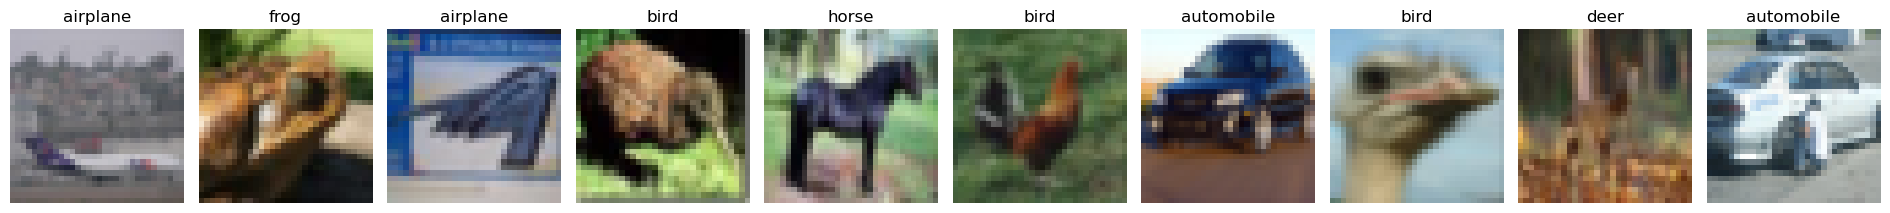

In [ ]:
# ==================== Визуализация ====================
def show_images(dataset, n=10):
    fig, axes = plt.subplots(1, n, figsize=(19,5))
    for i in range(n):
        img = dataset[i]["img"]
        label = dataset[i]["label"]
        axes[i].imshow(img)
        axes[i].set_title(classes[label])
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

show_images(dataset["train"], 10)

In [ ]:
# ==================== Подготовка данных ====================
torch.manual_seed(42)
np.random.seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
])

def collate_fn(batch):
    images = [transform(x["img"]) for x in batch]
    labels = [x["label"] for x in batch]

    return {
        "img": torch.stack(images),
        "label": torch.tensor(labels)
    }

train_loader = DataLoader(dataset["train"], batch_size=64,
                          shuffle=True, collate_fn=collate_fn)

test_loader = DataLoader(dataset["test"], batch_size=64,
                         shuffle=False, collate_fn=collate_fn)


In [ ]:
# ==================== Модель ====================
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)

        self.fc1 = nn.Linear(64*8*8, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.dropout1(x)

        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout1(x)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)

        return x

In [ ]:
# ==================== Инициализация ====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Device:", device)

Device: cuda


In [ ]:
# ==================== Обучение ====================
num_epochs = 10

train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(num_epochs):

    # ----- TRAIN -----
    model.train()
    loss_sum, correct, total = 0, 0, 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        x = batch["img"].to(device)
        y = batch["label"].to(device)

        optimizer.zero_grad()

        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item()

        _, pred = torch.max(out, 1)
        total += y.size(0)
        correct += (pred == y).sum().item()

    train_loss = loss_sum / len(train_loader)
    train_acc = 100 * correct / total

    # ----- TEST -----
    model.eval()
    loss_sum, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Epoch {epoch+1} [Test]"):
            x = batch["img"].to(device)
            y = batch["label"].to(device)

            out = model(x)
            loss = criterion(out, y)

            loss_sum += loss.item()

            _, pred = torch.max(out, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()

    test_loss = loss_sum / len(test_loader)
    test_acc = 100 * correct / total

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"\nEpoch {epoch+1}:")
    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"Test  Loss: {test_loss:.4f} | Acc: {test_acc:.2f}%")

Epoch 1 [Test]: 100%|██████████| 157/157 [00:01<00:00, 83.81it/s]



Epoch 1:
Train Loss: 1.4372 | Acc: 47.82%
Test  Loss: 1.1603 | Acc: 58.34%


Epoch 2 [Test]: 100%|██████████| 157/157 [00:01<00:00, 86.37it/s]



Epoch 2:
Train Loss: 1.1163 | Acc: 60.31%
Test  Loss: 0.9584 | Acc: 66.22%


Epoch 3 [Test]: 100%|██████████| 157/157 [00:01<00:00, 84.93it/s]


...


Epoch 8:
Train Loss: 0.7248 | Acc: 74.37%
Test  Loss: 0.7352 | Acc: 75.17%


Epoch 9 [Test]: 100%|██████████| 157/157 [00:02<00:00, 69.29it/s]



Epoch 9:
Train Loss: 0.6966 | Acc: 75.45%
Test  Loss: 0.7464 | Acc: 74.07%


Epoch 10 [Test]: 100%|██████████| 157/157 [00:01<00:00, 85.30it/s]


Epoch 10:
Train Loss: 0.6704 | Acc: 76.11%
Test  Loss: 0.7262 | Acc: 74.98%


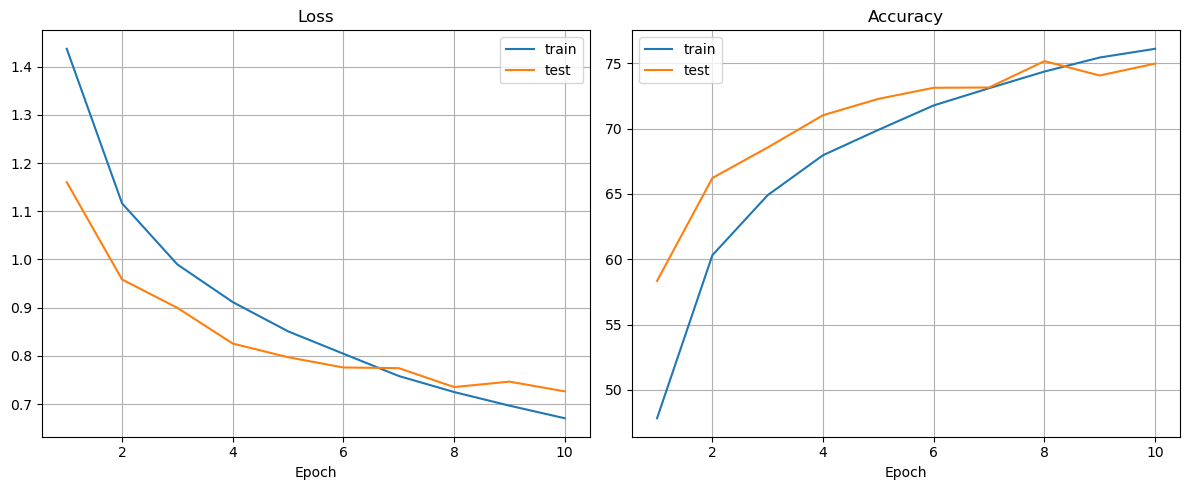

Best test accuracy: 75.17%


In [ ]:
# ==================== Графики ====================
epochs = range(1, num_epochs+1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="train")
plt.plot(epochs, test_losses, label="test")
plt.title("Loss")
plt.xlabel("Epoch")
plt.grid()
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label="train")
plt.plot(epochs, test_accs, label="test")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

print(f"Best test accuracy: {max(test_accs):.2f}%")

### Для улучшения качества можно попробовать
поработать с данными:

- аугментация

поработать с гипперпараметрами обучения
- размер батча
- лернинг рэйт(sheduller)
- раннюю остановку добавить что бы не переобучаться
- поменять архитектуру добавить слои свертки для извлечение более масштабных геометрических признаков
- добавить скип конекшены для проброса градиента
- добавить layer norm
- batch norm
- поменять оптимизатор добавить моментум или использовать моменты Нестерова

---
---

# Часть 2: Классификация изображений с предобработкой и аугментацией данных

In [ ]:
# ==================== Загрузка датасетов ====================
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

print("Загрузка датасетов...")

cifar_train = datasets.CIFAR10(DATA_DIR, train=True, download=True)
cifar_test  = datasets.CIFAR10(DATA_DIR, train=False, download=True)

fashion_train = datasets.FashionMNIST(DATA_DIR, train=True, download=True)
fashion_test  = datasets.FashionMNIST(DATA_DIR, train=False, download=True)

svhn_train = datasets.SVHN(DATA_DIR, split='train', download=True)
svhn_test  = datasets.SVHN(DATA_DIR, split='test', download=True)

print("Загрузка завершена")

Загрузка датасетов...


/home/penguin/miniconda3/envs/deep_learn_env/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Загрузка завершена


In [ ]:
# ==================== Анализ данных ====================
def inspect_dataset(name, dataset):
    img, label = dataset[0]
    img_np = np.array(img)

    print(f"\n{name}")
    print("Размер:", img.size)
    print("Форма:", img_np.shape)
    print("Каналы:", 1 if len(img_np.shape)==2 else img_np.shape[2])

inspect_dataset("CIFAR-10", cifar_train)
inspect_dataset("Fashion-MNIST", fashion_train)
inspect_dataset("SVHN", svhn_train)



CIFAR-10
Размер: (32, 32)
Форма: (32, 32, 3)
Каналы: 3

Fashion-MNIST
Размер: (28, 28)
Форма: (28, 28)
Каналы: 1

SVHN
Размер: (32, 32)
Форма: (32, 32, 3)
Каналы: 3


In [ ]:
# ==================== Аугментации ====================
def build_transform(is_train=True, is_rgb=True, pad=False,
                    flip=False, rot=None, color=False):

    t = []

    if pad:
        t.append(transforms.Pad(2))

    if is_train:
        if flip:
            t.append(transforms.RandomHorizontalFlip())

        if rot:
            t.append(transforms.RandomRotation(rot))

        if color:
            t.append(transforms.ColorJitter(0.2,0.2))

    t.append(transforms.ToTensor())

    if is_rgb:
        t.append(transforms.Normalize((0.5,)*3,(0.5,)*3))
    else:
        t.append(transforms.Normalize((0.5,),(0.5,)))

    return transforms.Compose(t)

In [ ]:
# ==================== Эксперименты ====================
EXPERIMENTS = {
    "CIFAR-10": [
        {"name":"baseline","flip":False,"rot":None,"color":False},
        {"name":"flip","flip":True,"rot":None,"color":False},
        {"name":"rot15","flip":False,"rot":15,"color":False},
        {"name":"color","flip":False,"rot":None,"color":True},
        {"name":"full","flip":True,"rot":15,"color":True},
    ],
    "Fashion-MNIST": [
        {"name":"baseline","flip":False,"rot":None,"color":False},
        {"name":"flip","flip":True,"rot":None,"color":False},
        {"name":"rot10","flip":False,"rot":10,"color":False},
        {"name":"combo","flip":True,"rot":10,"color":False},
    ],
    "SVHN": [
        {"name":"baseline","flip":False,"rot":None,"color":False},
        {"name":"rot10","flip":False,"rot":10,"color":False},
        {"name":"color","flip":False,"rot":None,"color":True},
        {"name":"combo","flip":False,"rot":10,"color":True},
    ]
}

In [ ]:
# ==================== Модель ====================
class SimpleCNN(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.25)

        self.fc1 = nn.Linear(64*8*8, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.dropout(x)

        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout(x)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
# ==================== Обучение ====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(train_loader, test_loader, in_channels, epochs=10):
    model = SimpleCNN(in_channels).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)

            loss.backward()
            optimizer.step()

            _, pred = torch.max(out,1)
            total += y.size(0)
            correct += (pred==y).sum().item()

        train_acc = 100 * correct / total

        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)

                out = model(x)
                _, pred = torch.max(out,1)

                total += y.size(0)
                correct += (pred==y).sum().item()

        test_acc = 100 * correct / total
        best_acc = max(best_acc, test_acc)

        print(f"Epoch {epoch+1}: Train {train_acc:.2f}% | Test {test_acc:.2f}%")

    return best_acc

In [ ]:
# ==================== Запуск экспериментов ====================
def run(dataset_name, train_ds, test_ds, in_channels, pad=False):
    results = []

    for exp in EXPERIMENTS[dataset_name]:
        print(f"\n{dataset_name} | {exp['name']}")

        train_ds.transform = build_transform(
            True, in_channels==3, pad,
            exp["flip"], exp["rot"], exp["color"]
        )
        test_ds.transform = build_transform(
            False, in_channels==3, pad
        )

        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
        test_loader  = DataLoader(test_ds, batch_size=64)

        acc = train_model(train_loader, test_loader, in_channels)

        results.append({
            "dataset": dataset_name,
            "experiment": exp["name"],
            "accuracy": acc
        })

    return results


results = []
results += run("CIFAR-10", cifar_train, cifar_test, 3)
results += run("Fashion-MNIST", fashion_train, fashion_test, 1, pad=True)
results += run("SVHN", svhn_train, svhn_test, 3)




CIFAR-10 | baseline
Epoch 1: Train 50.90% | Test 61.60%
Epoch 2: Train 64.33% | Test 68.32%
Epoch 3: Train 70.46% | Test 70.76%
Epoch 4: Train 74.42% | Test 71.95%
Epoch 5: Train 77.78% | Test 73.96%
Epoch 6: Train 81.15% | Test 74.08%
Epoch 7: Train 84.00% | Test 73.75%
Epoch 8: Train 86.15% | Test 74.17%
Epoch 9: Train 88.36% | Test 74.99%
Epoch 10: Train 89.96% | Test 74.99%

CIFAR-10 | flip
Epoch 1: Train 51.29% | Test 61.81%
Epoch 2: Train 63.95% | Test 68.71%
Epoch 3: Train 68.46% | Test 71.50%
Epoch 4: Train 72.43% | Test 72.80%
Epoch 5: Train 74.94% | Test 73.71%
Epoch 6: Train 76.83% | Test 74.10%
Epoch 7: Train 78.98% | Test 75.20%
Epoch 8: Train 80.70% | Test 75.02%
Epoch 9: Train 82.20% | Test 76.30%
Epoch 10: Train 83.08% | Test 75.73%

CIFAR-10 | rot15
Epoch 1: Train 47.27% | Test 57.98%
Epoch 2: Train 58.52% | Test 62.86%
Epoch 3: Train 63.51% | Test 67.86%
Epoch 4: Train 66.05% | Test 68.14%
Epoch 5: Train 69.03% | Test 69.74%
Epoch 6: Train 70.94% | Test 71.36%
Epoch 

In [48]:
# ==================== Таблица результатов ====================
results_2_df = pd.DataFrame(results)

results_2_df = df.pivot(index="experiment", columns="dataset", values="accuracy")
print("\nРезультаты:")
results_2_df


Результаты:


dataset,CIFAR-10,Fashion-MNIST,SVHN
experiment,,,
baseline,74.99,92.41,91.210817
color,75.22,NaN,91.233866
combo,NaN,92.12,90.734481
flip,76.30,92.43,NaN
full,75.53,NaN,NaN
rot10,NaN,92.26,91.203135
rot15,73.55,NaN,NaN


##  Выводы по части 2 (аугментация данных)

1. Влияние аугментации зависит от структуры датасета.
   На **CIFAR-10** наблюдается умеренное улучшение по сравнению с baseline (74.99% → до 76.30%), тогда как на **Fashion-MNIST** изменения незначительны (≈92.1–92.4%), а на **SVHN** результаты остаются стабильными около 91.2%.

2. Наилучшие результаты по тестовой точности (%):

   * **CIFAR-10**: *horizontal flip* → **76.30%**
   * **Fashion-MNIST**: *flip* → **92.43%** (очень близко к baseline)
   * **SVHN**: *baseline / color augmentation* → **~91.23%**

3. Горизонтальное отражение даёт наиболее устойчивый эффект для CIFAR-10, тогда как цветовые преобразования (ColorJitter) дают небольшой прирост на SVHN, где важны цветовые характеристики.

4. Повороты (rotation 10–15°) в среднем либо не дают прироста, либо ухудшают качество (например, CIFAR-10: 73.55% при rot15), что указывает на чувствительность моделей к геометрическим искажениям без соответствующей адаптации архитектуры.

5. Комбинированные аугментации не гарантируют улучшение: в ряде случаев наблюдается деградация качества (full augmentation на CIFAR-10), что показывает наличие переусложнения входного распределения без выигрыша в обобщении.

6. В целом, аугментация работает как датасет-специфический инструмент: её эффективность определяется соответствием преобразований реальным инвариантностям данных, а не количеством применённых техник.


---
---

# Часть 3 Оптимизация архитектуры (CIFAR-10)

In [ ]:
# ==================== Данные ====================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),
                         (0.2470,0.2435,0.2616))
])

cifar_train.transform = transform
cifar_test.transform  = transform

train_loader = DataLoader(cifar_train, batch_size=64, shuffle=True)
test_loader  = DataLoader(cifar_test,  batch_size=64)


In [ ]:
# ==================== Архитектуры ====================

# ----- БАЗОВАЯ -----
class CNN_Base(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*8*8,512)
        self.fc2 = nn.Linear(512,10)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0),-1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [43]:
# ----- ВАРИАНТ A: больше фильтров -----
class CNN_A(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,64,3,padding=1)
        self.conv2 = nn.Conv2d(64,128,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(128*8*8,512)
        self.fc2 = nn.Linear(512,10)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0),-1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


In [44]:
# ----- ВАРИАНТ B: BatchNorm -----
class CNN_B(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*8*8,512)
        self.fc2 = nn.Linear(512,10)

    def forward(self,x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0),-1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [45]:
# ----- ВАРИАНТ C: Dropout + доп. слой -----
class CNN_C(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.5)

        self.fc1 = nn.Linear(64*8*8,512)
        self.fc2 = nn.Linear(512,256)
        self.fc3 = nn.Linear(256,10)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.dropout1(x)

        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout1(x)

        x = x.view(x.size(0),-1)

        x = F.relu(self.fc1(x))
        x = self.dropout2(x)

        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [ ]:
# ==================== Обучение ====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(model, epochs=10):
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    train_accs, test_accs = [], []

    for epoch in range(epochs):

        # TRAIN
        model.train()
        correct, total = 0, 0

        for x,y in train_loader:
            x,y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out,y)

            loss.backward()
            optimizer.step()

            _,pred = torch.max(out,1)
            total += y.size(0)
            correct += (pred==y).sum().item()

        train_acc = 100 * correct / total

        # TEST
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for x,y in test_loader:
                x,y = x.to(device), y.to(device)

                out = model(x)
                _,pred = torch.max(out,1)

                total += y.size(0)
                correct += (pred==y).sum().item()

        test_acc = 100 * correct / total

        train_accs.append(train_acc)
        test_accs.append(test_acc)

        print(f"Epoch {epoch+1}: Train {train_acc:.2f}% | Test {test_acc:.2f}%")

    return train_accs, test_accs

In [47]:
# ==================== Запуск ====================
experiments = {
    "Baseline": CNN_Base,
    "A (filters)": CNN_A,
    "B (BatchNorm)": CNN_B,
    "C (Dropout+FC)": CNN_C
}

results = []

for name, model_class in experiments.items():
    print(f"\n=== {name} ===")

    train_accs, test_accs = train_model(model_class())

    results.append({
        "model": name,
        "best_test_acc": max(test_accs),
        "final_test_acc": test_accs[-1],
        "final_train_acc": train_accs[-1],
        "overfitting_gap": train_accs[-1] - test_accs[-1]
    })


=== Baseline ===
Epoch 1: Train 55.17% | Test 63.86%
Epoch 2: Train 69.85% | Test 69.11%
Epoch 3: Train 76.45% | Test 71.90%
Epoch 4: Train 81.85% | Test 73.40%
Epoch 5: Train 87.18% | Test 73.84%
Epoch 6: Train 91.56% | Test 72.57%
Epoch 7: Train 94.83% | Test 72.51%
Epoch 8: Train 96.58% | Test 72.66%
Epoch 9: Train 97.05% | Test 72.14%
Epoch 10: Train 97.74% | Test 72.64%

=== A (filters) ===
Epoch 1: Train 55.20% | Test 61.91%
Epoch 2: Train 69.26% | Test 69.65%
Epoch 3: Train 76.35% | Test 71.06%
Epoch 4: Train 81.65% | Test 73.06%
Epoch 5: Train 87.08% | Test 72.40%
Epoch 6: Train 91.45% | Test 73.00%
Epoch 7: Train 94.64% | Test 72.69%
Epoch 8: Train 95.74% | Test 70.92%
Epoch 9: Train 97.04% | Test 72.17%
Epoch 10: Train 97.26% | Test 71.42%

=== B (BatchNorm) ===
Epoch 1: Train 54.89% | Test 61.86%
Epoch 2: Train 68.05% | Test 69.58%
Epoch 3: Train 73.63% | Test 72.80%
Epoch 4: Train 77.22% | Test 73.26%
Epoch 5: Train 80.39% | Test 73.43%
Epoch 6: Train 83.24% | Test 73.91%


In [49]:
# ==================== Таблица ====================
results_3_df = pd.DataFrame(results)

print("\nРезультаты:")
results_3_df


Результаты:


,model,best_test_acc,final_test_acc,final_train_acc,overfitting_gap
0,Baseline,73.84,72.64,97.742,25.102
1,A (filters),73.06,71.42,97.260,25.840
2,B (BatchNorm),74.66,74.59,92.070,17.480
3,C (Dropout+FC),74.86,74.12,74.150,0.030


##  Выводы по части 3 (оптимизация архитектуры)

1. Увеличение числа фильтров (A) не дало улучшения качества:
   **73.84% → 73.06% (best test accuracy)**. При этом переобучение осталось высоким (gap ≈ 25.8%), что указывает на рост сложности модели без улучшения обобщающей способности.

2. Добавление Batch Normalization (B) дало наиболее стабильный эффект среди базовых модификаций:

   * рост качества до **74.66%**
   * значительное снижение переобучения (**97.26% → 92.07% train vs test gap ≈ 17.48%**)
     Это подтверждает, что BatchNorm улучшает стабильность обучения и снижает внутреннее смещение распределений.

3. Архитектура с усиленной регуляризацией и дополнительным полносвязным слоем (C) показала:

   * максимальную тестовую точность: **74.86%**
   * практически отсутствующее переобучение (**gap ≈ 0.03%**)
     Однако при этом наблюдается снижение train accuracy до ~74%, что указывает на **недообучение (underfitting)** из-за сильной регуляризации.

4. Общий вывод:

   * BatchNorm улучшает баланс между качеством и стабильностью обучения
   * увеличение фильтров без изменения регуляризации неэффективно
   * сильная регуляризация (Dropout + FC) полностью подавляет переобучение, но может снижать обучаемость модели
   * оптимальный компромисс в рамках эксперимента — вариант **B (BatchNorm)** или близкая к нему конфигурация


# Часть 4 Настройка гиперпараметров (CIFAR-10)

In [50]:
# ==================== 1. Данные ====================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),
                         (0.2470,0.2435,0.2616))
])

cifar_train.transform = transform
cifar_test.transform  = transform


In [61]:
# ==================== 2. МОДЕЛИ ====================

# ----- БАЗОВАЯ 2 СЛОЯ -----
class CNN_2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*8*8,512)
        self.fc2 = nn.Linear(512,10)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0),-1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


# ----- ГЛУБОКАЯ 4 СЛОЯ -----
class CNN_4(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.conv3 = nn.Conv2d(64,128,3,padding=1)
        self.conv4 = nn.Conv2d(128,128,3,padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4,4))

        self.fc1 = nn.Linear(128*4*4, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))

        x = self.adaptive_pool(x)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [62]:
# ==================== 3. TRAIN LOOP ====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(model, optimizer, train_loader, test_loader, epochs=8):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    train_accs, test_accs = [], []

    for epoch in range(epochs):

        # ----- TRAIN -----
        model.train()
        correct, total = 0, 0

        for x,y in train_loader:
            x,y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out,y)

            loss.backward()
            optimizer.step()

            _,pred = torch.max(out,1)
            total += y.size(0)
            correct += (pred==y).sum().item()

        train_acc = 100 * correct / total

        # ----- TEST -----
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for x,y in test_loader:
                x,y = x.to(device), y.to(device)

                out = model(x)
                _,pred = torch.max(out,1)

                total += y.size(0)
                correct += (pred==y).sum().item()

        test_acc = 100 * correct / total

        train_accs.append(train_acc)
        test_accs.append(test_acc)

        print(f"Epoch {epoch+1}: Train {train_acc:.2f}% | Test {test_acc:.2f}%")

    return train_accs, test_accs

In [63]:
# ==================== 4. EXPERIMENTS ====================
results = []

train_loader_64 = DataLoader(cifar_train, batch_size=64, shuffle=True)
test_loader_64  = DataLoader(cifar_test, batch_size=64)

train_loader_16 = DataLoader(cifar_train, batch_size=16, shuffle=True)
test_loader_16  = DataLoader(cifar_test, batch_size=16)

train_loader_128 = DataLoader(cifar_train, batch_size=128, shuffle=True)
test_loader_128  = DataLoader(cifar_test, batch_size=128)


# ----- 1. LEARNING RATE -----
def run_lr_experiments():

    models = {
        "SGD_lr=0.001": optim.SGD,
        "Adam": optim.Adam,
    }

    lr_results = []

    for name, opt in models.items():
        model = CNN_2()

        optimizer = opt(model.parameters(), lr=0.001)

        _, test_accs = train_model(model, optimizer,
                                    train_loader_64, test_loader_64)

        lr_results.append({
            "experiment": name,
            "best_test_acc": max(test_accs),
            "final_test_acc": test_accs[-1]
        })

    return lr_results


# ----- 2. BATCH SIZE -----
def run_batch_size_experiments():

    batch_results = []

    for name, loader in {
        "batch_16": train_loader_16,
        "batch_64": train_loader_64,
        "batch_128": train_loader_128
    }.items():

        model = CNN_2()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        _, test_accs = train_model(model, optimizer, loader, test_loader_64)

        batch_results.append({
            "experiment": name,
            "best_test_acc": max(test_accs),
            "final_test_acc": test_accs[-1]
        })

    return batch_results


# ----- 3. DEPTH -----
def run_depth_experiments():

    depth_results = []

    for name, model in {
        "2_layers": CNN_2,
        "4_layers": CNN_4
    }.items():

        model = model()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        _, test_accs = train_model(model, optimizer,
                                   train_loader_64, test_loader_64)

        depth_results.append({
            "experiment": name,
            "best_test_acc": max(test_accs),
            "final_test_acc": test_accs[-1]
        })

    return depth_results

In [65]:
results += run_lr_experiments()

Epoch 1: Train 20.83% | Test 27.91%
Epoch 2: Train 28.31% | Test 29.81%
Epoch 3: Train 30.64% | Test 32.40%
Epoch 4: Train 33.41% | Test 35.65%
Epoch 5: Train 36.25% | Test 38.30%
Epoch 6: Train 38.82% | Test 40.37%
Epoch 7: Train 40.80% | Test 42.15%
Epoch 8: Train 42.86% | Test 43.85%
Epoch 1: Train 55.65% | Test 65.32%
Epoch 2: Train 70.06% | Test 70.70%
Epoch 3: Train 77.19% | Test 73.13%
Epoch 4: Train 83.67% | Test 73.43%
Epoch 5: Train 89.77% | Test 73.37%
Epoch 6: Train 93.87% | Test 72.37%
Epoch 7: Train 96.20% | Test 72.76%
Epoch 8: Train 97.00% | Test 72.18%


In [66]:
results += run_batch_size_experiments()


Epoch 1: Train 56.62% | Test 65.96%
Epoch 2: Train 70.89% | Test 70.03%
Epoch 3: Train 77.83% | Test 71.27%
Epoch 4: Train 84.28% | Test 70.96%
Epoch 5: Train 89.45% | Test 70.48%
Epoch 6: Train 92.86% | Test 71.05%
Epoch 7: Train 94.70% | Test 69.91%
Epoch 8: Train 95.55% | Test 70.39%
Epoch 1: Train 55.37% | Test 63.96%
Epoch 2: Train 69.81% | Test 70.39%
Epoch 3: Train 76.91% | Test 72.08%
Epoch 4: Train 83.09% | Test 72.72%
Epoch 5: Train 88.79% | Test 73.28%
Epoch 6: Train 93.55% | Test 72.61%
Epoch 7: Train 96.09% | Test 72.66%
Epoch 8: Train 97.02% | Test 72.57%
Epoch 1: Train 53.44% | Test 60.92%
Epoch 2: Train 68.10% | Test 68.29%
Epoch 3: Train 74.58% | Test 71.03%
Epoch 4: Train 80.20% | Test 73.18%
Epoch 5: Train 85.45% | Test 73.79%
Epoch 6: Train 90.31% | Test 73.08%
Epoch 7: Train 94.42% | Test 73.40%
Epoch 8: Train 96.93% | Test 72.43%


In [64]:
results += run_depth_experiments()

Epoch 1: Train 55.03% | Test 65.33%
Epoch 2: Train 69.97% | Test 69.90%
Epoch 3: Train 77.03% | Test 72.45%
Epoch 4: Train 83.00% | Test 72.36%
Epoch 5: Train 88.93% | Test 73.28%
Epoch 6: Train 93.35% | Test 72.34%
Epoch 7: Train 95.85% | Test 72.67%
Epoch 8: Train 96.95% | Test 72.78%
Epoch 1: Train 46.91% | Test 61.08%
Epoch 2: Train 66.81% | Test 69.72%
Epoch 3: Train 74.43% | Test 72.71%
Epoch 4: Train 78.31% | Test 75.68%
Epoch 5: Train 81.55% | Test 74.42%
Epoch 6: Train 84.71% | Test 75.72%
Epoch 7: Train 86.72% | Test 75.14%
Epoch 8: Train 88.78% | Test 76.21%


In [68]:
# ==================== 6. TABLE ====================
results_4_df = pd.DataFrame(results)
print("\nРезультаты:")
results_4_df


Результаты:


,experiment,best_test_acc,final_test_acc
0,2_layers,73.28,72.78
1,4_layers,76.21,76.21
2,SGD_lr=0.001,43.85,43.85
3,Adam,73.43,72.18
4,batch_16,71.27,70.39
5,batch_64,73.28,72.57
6,batch_128,73.79,72.43


## Выводы по части 4 (гиперпараметры)

1. **Глубина сети оказалась наиболее значимым фактором качества.**
   Модель с 4 сверточными слоями показала лучший результат:
   **73.28% → 76.21% (best test accuracy)** по сравнению с 2 слоями.
   Это подтверждает, что увеличение глубины улучшает извлечение иерархических признаков и повышает обобщающую способность модели.

2. **Оптимизатор оказывает критическое влияние на обучение.**

   * Adam: **73.43%**
   * SGD (lr=0.001): **43.85%**
     SGD без дополнительной настройки (momentum, scheduler) показал резкое падение качества, что указывает на его чувствительность к гиперпараметрам.
     Adam обеспечивает существенно более стабильное и эффективное обучение.

3. **Размер batch size влияет умеренно, но стабильно:**

   * batch=16 → **71.27%**
   * batch=64 → **73.28%**
   * batch=128 → **73.79% (best final: 72.43%)**

   Более крупный batch улучшает стабильность градиента, но эффект насыщается после 64–128.

4. **Итог по гиперпараметрам:**

   * ключевой фактор улучшения — **глубина сети**
   * оптимальный оптимизатор — **Adam**
   * лучший batch size — **64–128 (с небольшим преимуществом 128)**
   * SGD без настройки существенно ухудшает результат и требует scheduler/momentum для конкурентоспособности

5. **Общий вывод:**
   качество модели определяется сочетанием архитектуры и оптимизации: увеличение глубины даёт наибольший прирост, тогда как выбор оптимизатора и batch size влияет на стабильность и скорость сходимости, но не компенсирует слабую архитектуру.
